In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Patch

In [2]:
COLORS = {
    "ok":   ("#2E8B57", "przejście poprawne"),
    "blur": ("#E3A63B", "rozmyte / przesunięte"),
    "bad":  ("#B03A2E", "artefakty lub brak przejścia"),
    "not-enough": ("#FDDFA3", "nie osiągnięto P = 1"),
    "none": ("#DCDCDC", "brak wyniku"),
}

TRANSITIONS = ["AC", "AB", "BCb"]

FEATURE_COUNTS = [30, 20, 12]

MODELS = [
    "K-średnich",
    "Grupowanie aglomeracyjne",
    "Grupowanie spektralne",
    "Mieszanina Gaussowska",
    "Przesunięcie średniej",
    "BIRCH",
    "Bayesowska Miesz. Gaussowska",
    "DBSCAN",
]


In [3]:
STATUS = {
    (transition, feature_count, model): ("none", "none")
    for transition in TRANSITIONS
    for feature_count in FEATURE_COUNTS
    for model in MODELS
}

In [4]:
def plot_status_matrix(
    status,
    output_png="status_matrix.png",
    output_pdf="status_matrix.pdf"
):

    columns = [
        (transition, feature_count)
        for transition in TRANSITIONS
        for feature_count in FEATURE_COUNTS
    ]

    n_columns = len(columns)
    n_models = len(MODELS)

    fig, ax = plt.subplots(
        figsize=(12.4, 6.0)
    )


    for column_idx, (transition, feature_count) in enumerate(columns):

        for model_idx, model in enumerate(MODELS):

            without_std, with_std = status.get(
                (transition, feature_count, model),
                ("none", "none")
            )

            x0, x1 = column_idx, column_idx + 1
            y0, y1 = model_idx, model_idx + 1

            ax.add_patch(
                Polygon(
                    [
                        (x0, y0),
                        (x0, y1),
                        (x1, y1),
                    ],
                    facecolor=COLORS[without_std][0],
                    edgecolor="white",
                    linewidth=1.2,
                )
            )


            ax.add_patch(
                Polygon(
                    [
                        (x0, y0),
                        (x1, y0),
                        (x1, y1),
                    ],
                    facecolor=COLORS[with_std][0],
                    edgecolor="white",
                    linewidth=1.2,
                )
            )


    for column_idx in (3, 6):
        ax.axvline(
            column_idx,
            color="black",
            linewidth=2
        )

    ax.set_xlim(0, n_columns)
    ax.set_ylim(0, n_models)
    ax.invert_yaxis()

    ax.set_xticks(
        np.arange(n_columns) + 0.5,
        [str(feature_count) for _, feature_count in columns],
        fontsize=10
    )

    ax.set_yticks(
        np.arange(n_models) + 0.5,
        MODELS,
        fontsize=10
    )


    for idx, transition in enumerate(TRANSITIONS):

        ax.text(
            (idx + 0.5) * len(FEATURE_COUNTS),
            -0.35,
            transition,
            ha="center",
            fontsize=14,
            fontweight="bold"
        )

    ax.set_xlabel(
        "liczba cech",
        fontsize=10,
        color="0.35",
        labelpad=8
    )

    ax.tick_params(length=0)


    for spine in ax.spines.values():
        spine.set_visible(False)


    ax.legend(
        handles=[
            Patch(
                facecolor=COLORS["ok"][0],
                label="przejście poprawne"
            ),
            Patch(
                facecolor=COLORS["not-enough"][0],
                label="Przejście poprawne, lecz nie osiągnięto P(d_j)=1"
            ),
            Patch(
                facecolor=COLORS["blur"][0],
                label="rozmyte / przesunięte"
            ),
            Patch(
                facecolor=COLORS["bad"][0],
                label="artefakty lub brak przejścia"
            ),
        ],
        loc="upper left",
        bbox_to_anchor=(1.01, 1.0),
        fontsize=9,
        frameon=False,
    )

    ax.text(
        1.015,
        0.42,
        "w komórce:\n"
        "◣  dolny-lewy — bez standaryzacji\n"
        "◥  górny-prawy — ze standaryzacją",
        transform=ax.transAxes,
        fontsize=9,
        va="top",
        color="0.25"
    )

    fig.suptitle(
        "Wpływ standaryzacji na jakość detekcji przejścia - modele nienadzorowane",
        fontsize=14,
        y=0.97
    )

    fig.subplots_adjust(
        left=0.20,
        right=0.76,
        top=0.84,
        bottom=0.10
    )

    # fig.savefig(
    #     output_png,
    #     dpi=300,
    #     bbox_inches="tight"
    # )

    fig.savefig(
        output_pdf,
        bbox_inches="tight"
    )

    plt.show()

    return fig, ax


In [5]:
STATUS[("AB", 12, "K-średnich")] = ("bad", "bad")
STATUS[("AB", 20, "K-średnich")] = ("bad", "bad")
STATUS[("AB", 30, "K-średnich")] = ("bad", "bad")

STATUS[("AB", 12, "Grupowanie aglomeracyjne")] = ("bad", "bad")
STATUS[("AB", 20, "Grupowanie aglomeracyjne")] = ("bad", "ok")
STATUS[("AB", 30, "Grupowanie aglomeracyjne")] = ("bad", "ok")


STATUS[("AB", 30, "Przesunięcie średniej")] = ("not-enough", "bad")
STATUS[("AB", 20, "Przesunięcie średniej")] = ("not-enough", "ok")
STATUS[("AB", 12, "Przesunięcie średniej")] = ("not-enough", "bad")

STATUS[("AB", 12, "BIRCH")] = ("bad", "ok")
STATUS[("AB", 20, "BIRCH")] = ("bad", "ok")
STATUS[("AB", 30, "BIRCH")] = ("bad", "ok")


STATUS[("AB", 12, "Grupowanie spektralne")] = ("bad", "bad")
STATUS[("AB", 20, "Grupowanie spektralne")] = ("bad", "bad")
STATUS[("AB", 30, "Grupowanie spektralne")] = ("bad", "bad")
STATUS[("AB", 12, "Mieszanina Gaussowska")] = ("bad", "bad")
STATUS[("AB", 20, "Mieszanina Gaussowska")] = ("bad", "bad")
STATUS[("AB", 30, "Mieszanina Gaussowska")] = ("bad", "bad")

STATUS[("AB", 12, "Bayesowska Miesz. Gaussowska")] = ("bad", "bad")
STATUS[("AB", 20, "Bayesowska Miesz. Gaussowska")] = ("bad", "bad")
STATUS[("AB", 30, "Bayesowska Miesz. Gaussowska")] = ("bad", "bad")


STATUS[("AC", 12, "DBSCAN")] = ("bad", "bad")
STATUS[("AC", 20, "DBSCAN")] = ("bad", "bad")
STATUS[("AC", 30, "DBSCAN")] = ("bad", "bad")
STATUS[("BCb", 12, "DBSCAN")] = ("bad", "bad")
STATUS[("BCb", 20, "DBSCAN")] = ("bad", "bad")
STATUS[("BCb", 30, "DBSCAN")] = ("bad", "bad")
STATUS[("AB", 12, "DBSCAN")] = ("bad", "bad")
STATUS[("AB", 20, "DBSCAN")] = ("bad", "bad")
STATUS[("AB", 30, "DBSCAN")] = ("bad", "bad")



In [8]:
# ---------------------------------------------------------------- AC
STATUS[("AC", 12, "K-średnich")]                  = ("ok",   "blur")
STATUS[("AC", 20, "K-średnich")]                  = ("bad",  "ok")
STATUS[("AC", 30, "K-średnich")]                  = ("ok",   "ok")

STATUS[("AC", 12, "Grupowanie aglomeracyjne")]               = ("blur", "blur")
STATUS[("AC", 20, "Grupowanie aglomeracyjne")]               = ("bad",  "ok")
STATUS[("AC", 30, "Grupowanie aglomeracyjne")]               = ("ok",   "ok")

STATUS[("AC", 12, "Grupowanie spektralne")]                  = ("blur", "blur")
STATUS[("AC", 20, "Grupowanie spektralne")]                  = ("bad",  "blur")
STATUS[("AC", 30, "Grupowanie spektralne")]                  = ("blur", "blur")

STATUS[("AC", 12, "Mieszanina Gaussowska")]       = ("blur", "blur")
STATUS[("AC", 20, "Mieszanina Gaussowska")]       = ("blur", "blur")
STATUS[("AC", 30, "Mieszanina Gaussowska")]       = ("blur", "blur")

STATUS[("AC", 12, "Przesunięcie średniej")]       = ("bad", "bad")
STATUS[("AC", 20, "Przesunięcie średniej")]       = ("bad", "bad")
STATUS[("AC", 30, "Przesunięcie średniej")]       = ("bad", "bad")

STATUS[("AC", 12, "BIRCH")]                       = ("blur", "blur")
STATUS[("AC", 20, "BIRCH")]                       = ("bad",  "blur")
STATUS[("AC", 30, "BIRCH")]                       = ("ok",   "blur")

STATUS[("AC", 12, "Bayesowska Miesz. Gaussowska")] = ("blur", "blur")
STATUS[("AC", 20, "Bayesowska Miesz. Gaussowska")] = ("blur", "blur")
STATUS[("AC", 30, "Bayesowska Miesz. Gaussowska")] = ("blur", "blur")
# --------------------------------------------------------------- BCb
STATUS[("BCb", 12, "K-średnich")]                  = ("ok",   "ok")
STATUS[("BCb", 20, "K-średnich")]                  = ("ok",   "ok")
STATUS[("BCb", 30, "K-średnich")]                  = ("ok",   "ok")

STATUS[("BCb", 12, "Grupowanie aglomeracyjne")]               = ("blur", "blur")
STATUS[("BCb", 20, "Grupowanie aglomeracyjne")]               = ("blur",   "blur")
STATUS[("BCb", 30, "Grupowanie aglomeracyjne")]               = ("blur", "blur")

STATUS[("BCb", 12, "Grupowanie spektralne")]                  = ("ok",   "ok")
STATUS[("BCb", 20, "Grupowanie spektralne")]                  = ("ok",   "ok")
STATUS[("BCb", 30, "Grupowanie spektralne")]                  = ("ok",   "ok")

STATUS[("BCb", 12, "Mieszanina Gaussowska")]       = ("ok",   "ok")
STATUS[("BCb", 20, "Mieszanina Gaussowska")]       = ("ok",   "ok")
STATUS[("BCb", 30, "Mieszanina Gaussowska")]       = ("ok",   "ok")

STATUS[("BCb", 12, "Przesunięcie średniej")]       = ("blur", "blur")
STATUS[("BCb", 20, "Przesunięcie średniej")]       = ("blur", "blur")
STATUS[("BCb", 30, "Przesunięcie średniej")]       = ("blur", "blur")

STATUS[("BCb", 12, "BIRCH")]                       = ("blur", "blur")
STATUS[("BCb", 20, "BIRCH")]                       = ("blur",   "blur")
STATUS[("BCb", 30, "BIRCH")]                       = ("blur", "ok")

STATUS[("BCb", 12, "Bayesowska Miesz. Gaussowska")] = ("ok",   "ok")
STATUS[("BCb", 20, "Bayesowska Miesz. Gaussowska")] = ("ok",   "ok")
STATUS[("BCb", 30, "Bayesowska Miesz. Gaussowska")] = ("ok",   "blur")







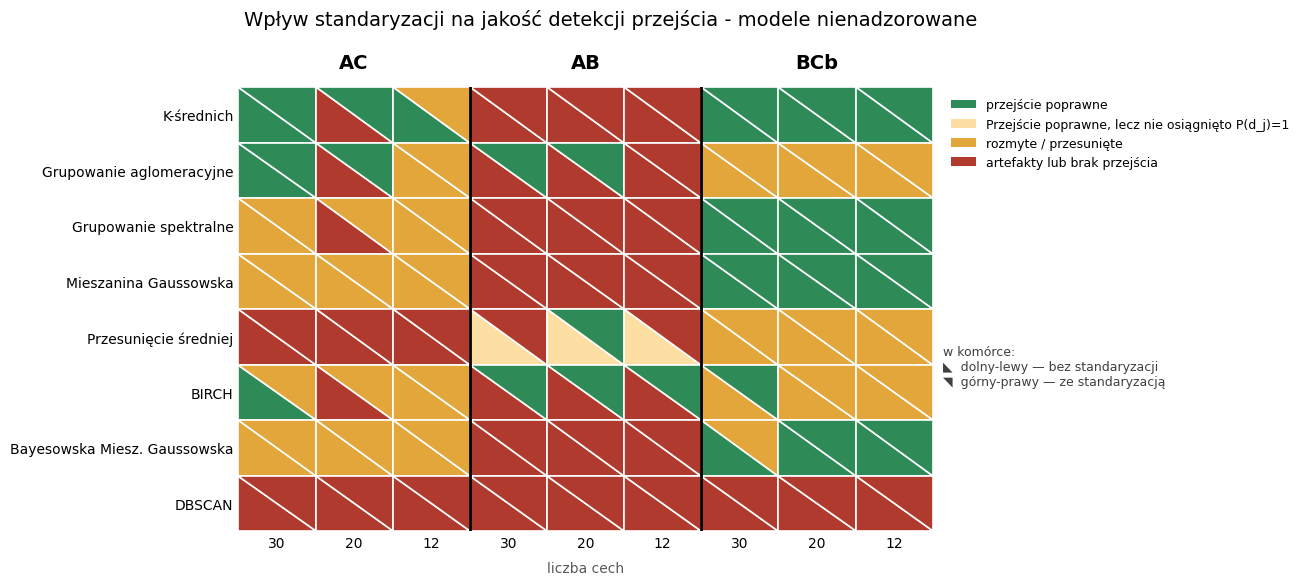

(<Figure size 1240x600 with 1 Axes>, <Axes: xlabel='liczba cech'>)

In [9]:
plot_status_matrix(
    STATUS,
    output_png="status_matrix.png",
    output_pdf="status_matrix.pdf"
)